In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import re
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)


In [2]:
# load the data into a dataframe object
df = pd.read_csv("Final_Dataset.csv",sep=",")

# replace "yes" with 1 and "no" with 0
df['Fraud'] = df['Fraud'].replace({'yes': 1, 'no': 0})

# filter item xy and nanintem xy out of the data
pattern = r'\b(?:(nan)+item|item)\s\d+\b'
df['Filings'] = df['Filings'].str.replace(pattern, '', regex=True)

df.head()

,Filings,Fraud
0,exhibits financial statements reports form 10...,1
1,principal accounting fees services material i...,0
2,exhibits financial statements schedules repor...,1
3,exhibits financial statement schedules report...,1
4,exhibits financial statement schedules report...,0


In [3]:
def initialize_classifiers(random_state=39):
    logistic_regression = make_pipeline(
        StandardScaler(with_mean=False),
        LogisticRegression(random_state=random_state, max_iter=1000)
    )
    gradient_boosting = GradientBoostingClassifier(random_state=random_state)
    svm = SVC(probability=True, random_state=random_state)

    # voting Classifier
    voting_classifier = VotingClassifier(
        estimators=[
            ('lr', logistic_regression),
            ('gb', gradient_boosting),
            ('svm', svm)
        ],
        voting='soft'
    )

    # stacking Classifier
    stacking_classifier = StackingClassifier(
        estimators=[
            ('lr', logistic_regression),
            ('gb', gradient_boosting),
            ('svm', svm)
        ],
        final_estimator=LogisticRegression(random_state=random_state)
    )

    return {
        "logistic_regression": logistic_regression,
        "gradient_boosting": gradient_boosting,
        "svm": svm,
        "voting_classifier": voting_classifier,
        "stacking_classifier": stacking_classifier
    }

In [4]:
# evaluation function
def evaluate_classifiers(classifiers, X_train, X_test, y_train, y_test):
    # train and evaluate each classifier
    for name, clf in classifiers.items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        y_pred_proba = clf.predict_proba(X_test)[:, 1] if hasattr(clf, "predict_proba") else None

        # generate classification report
        print(f"Classification Report for {name}:")
        print(classification_report(y_test, y_pred))

        # explicitly calculate accuracy
        accuracy = accuracy_score(y_test, y_pred)
        print(f"Accuracy for {name}: {accuracy:.4f}")

        # confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Fraudulent", "Fraudulent"])
        plt.figure(figsize=(6, 6))
        disp.plot(cmap='Blues', values_format='d')
        plt.grid(False) 
        plt.title(f"Confusion Matrix for {name}")
        plt.show()




Classification Report for logistic_regression:
              precision    recall  f1-score   support

           0       1.00      0.29      0.45        17
           1       0.59      1.00      0.74        17

    accuracy                           0.65        34
   macro avg       0.79      0.65      0.60        34
weighted avg       0.79      0.65      0.60        34

Accuracy for logistic_regression: 0.6471


<Figure size 600x600 with 0 Axes>

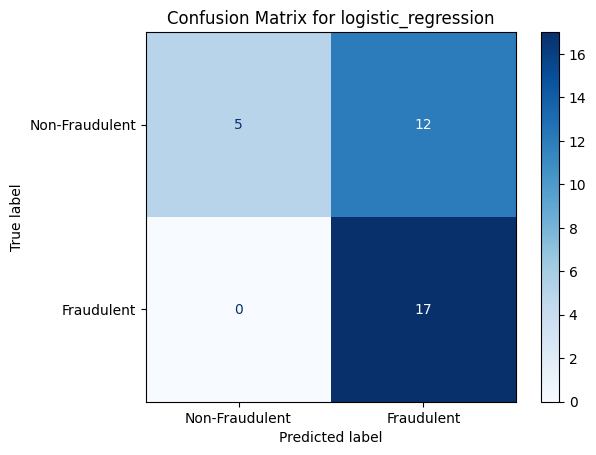

Classification Report for gradient_boosting:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34

Accuracy for gradient_boosting: 1.0000


<Figure size 600x600 with 0 Axes>

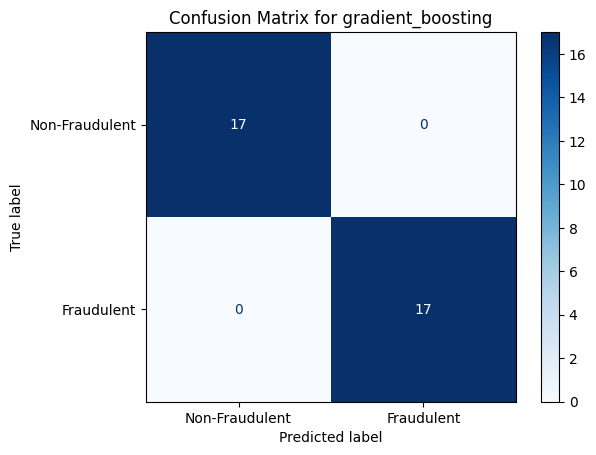

Classification Report for svm:
              precision    recall  f1-score   support

           0       0.85      0.65      0.73        17
           1       0.71      0.88      0.79        17

    accuracy                           0.76        34
   macro avg       0.78      0.76      0.76        34
weighted avg       0.78      0.76      0.76        34

Accuracy for svm: 0.7647


<Figure size 600x600 with 0 Axes>

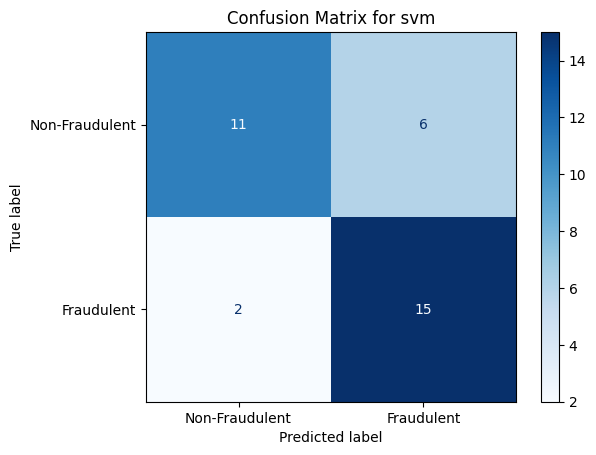

Classification Report for voting_classifier:
              precision    recall  f1-score   support

           0       1.00      0.65      0.79        17
           1       0.74      1.00      0.85        17

    accuracy                           0.82        34
   macro avg       0.87      0.82      0.82        34
weighted avg       0.87      0.82      0.82        34

Accuracy for voting_classifier: 0.8235


<Figure size 600x600 with 0 Axes>

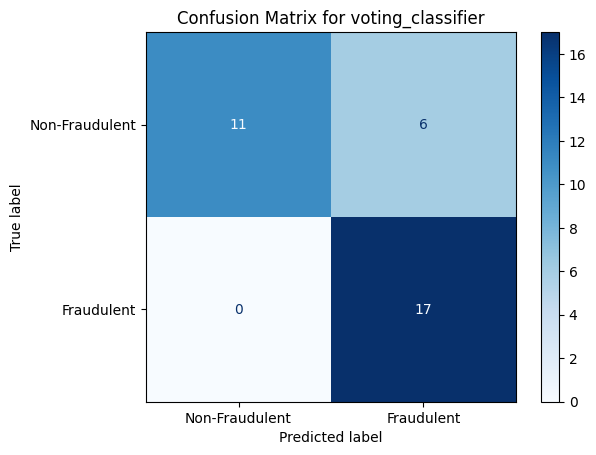

Classification Report for stacking_classifier:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34

Accuracy for stacking_classifier: 1.0000


<Figure size 600x600 with 0 Axes>

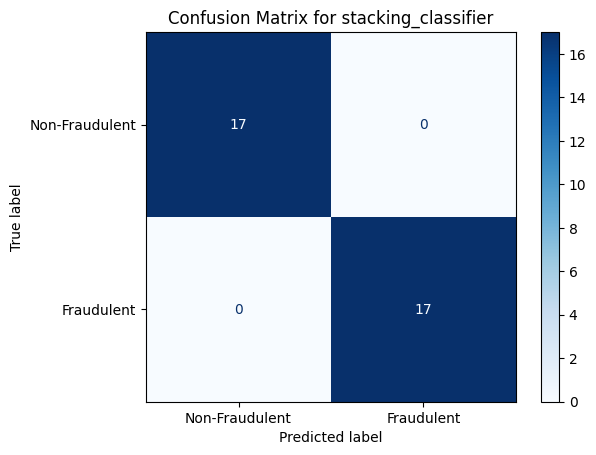

In [10]:
X = df['Filings']
y = df['Fraud']

classifiers_tfidf = initialize_classifiers(random_state=39)

lr_diversity = classifiers_tfidf["logistic_regression"]
gbc_diversity = classifiers_tfidf["gradient_boosting"]
svm_diversity = classifiers_tfidf["svm"]
voting_diversity = classifiers_tfidf["voting_classifier"]
stacking_diversity = classifiers_tfidf["stacking_classifier"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=39, stratify=y)

# ensure labels are numpy arrays
y_train = np.array(y_train)
y_test = np.array(y_test)

# transform the text data using TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# evaluate classifiers with the corrected data
evaluate_classifiers(
    classifiers=classifiers_tfidf,
    X_train=X_train_tfidf, 
    X_test=X_test_tfidf,  
    y_train=y_train,
    y_test=y_test
)



Classification Report for logistic_regression:
              precision    recall  f1-score   support

           0       0.90      0.53      0.67        17
           1       0.67      0.94      0.78        17

    accuracy                           0.74        34
   macro avg       0.78      0.74      0.72        34
weighted avg       0.78      0.74      0.72        34

Accuracy for logistic_regression: 0.7353


<Figure size 600x600 with 0 Axes>

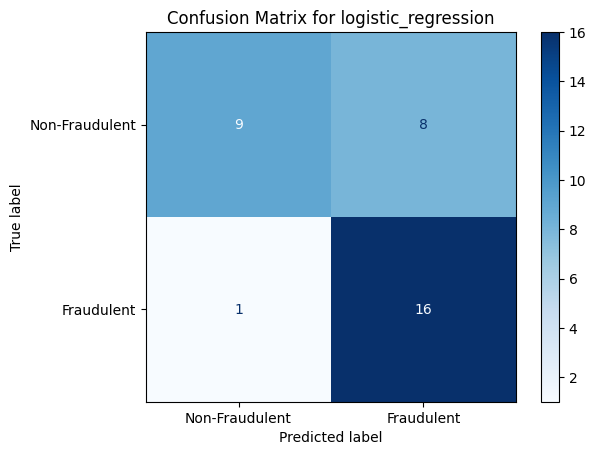

Classification Report for gradient_boosting:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34

Accuracy for gradient_boosting: 1.0000


<Figure size 600x600 with 0 Axes>

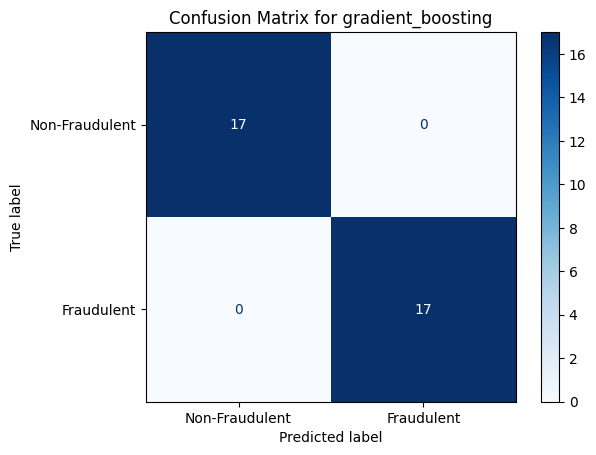

Classification Report for svm:
              precision    recall  f1-score   support

           0       1.00      0.82      0.90        17
           1       0.85      1.00      0.92        17

    accuracy                           0.91        34
   macro avg       0.93      0.91      0.91        34
weighted avg       0.92      0.91      0.91        34

Accuracy for svm: 0.9118


<Figure size 600x600 with 0 Axes>

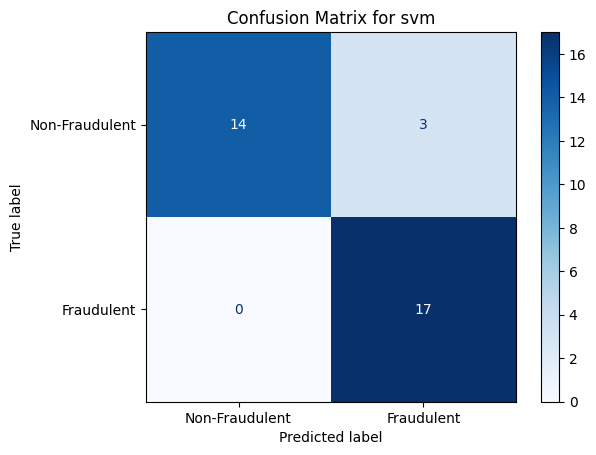

Classification Report for voting_classifier:
              precision    recall  f1-score   support

           0       1.00      0.82      0.90        17
           1       0.85      1.00      0.92        17

    accuracy                           0.91        34
   macro avg       0.93      0.91      0.91        34
weighted avg       0.92      0.91      0.91        34

Accuracy for voting_classifier: 0.9118


<Figure size 600x600 with 0 Axes>

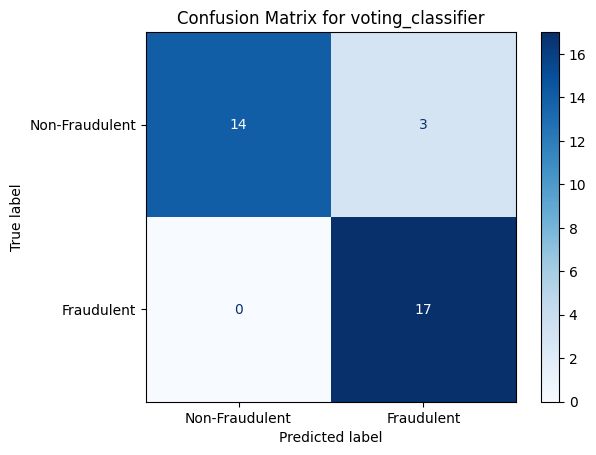

Classification Report for stacking_classifier:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34

Accuracy for stacking_classifier: 1.0000


<Figure size 600x600 with 0 Axes>

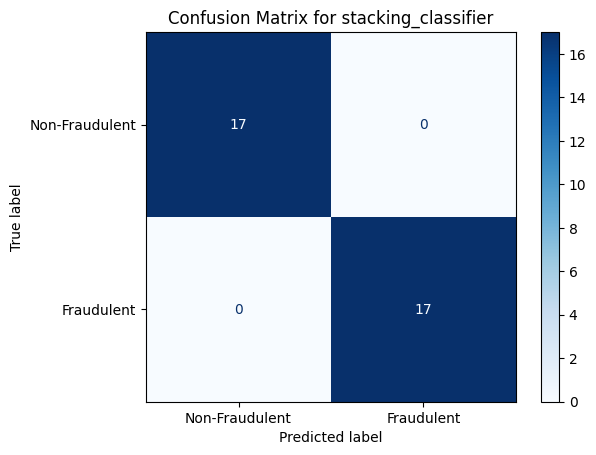

In [5]:
X = df['Filings']
y = df['Fraud']

classifiers_tfidf = initialize_classifiers(random_state=8)

lr_diversity = classifiers_tfidf["logistic_regression"]
gbc_diversity = classifiers_tfidf["gradient_boosting"]
svm_diversity = classifiers_tfidf["svm"]
voting_diversity = classifiers_tfidf["voting_classifier"]
stacking_diversity = classifiers_tfidf["stacking_classifier"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=8, stratify=y)

y_train = np.array(y_train)
y_test = np.array(y_test)

tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

evaluate_classifiers(
    classifiers=classifiers_tfidf,
    X_train=X_train_tfidf, 
    X_test=X_test_tfidf,  
    y_train=y_train,
    y_test=y_test
)



